# Analisis de Fraude

Lucho Ene / Jan | 2022 <br>
You Can't Always Get What You Want by Rolling Stones

###  Credit Card Fraud Detection Dataset

Este dataset contiene información sobre transacciones realizadas con tarjetas de crédito por titulares europeos durante septiembre de 2013. Las transacciones corresponden a un período de aproximadamente dos días.

El objetivo del dataset es desarrollar modelos de Machine Learning capaces de detectar transacciones fraudulentas.

Cuenta con **284.807** transacciones, de las cuales **492** son fraudulentas, por lo que presenta un fuerte desbalance entre las clases.

---

####  Variables del dataset

El dataset contiene 31 variables:

| Variable | Tipo | Descripción |
| :--- | :--- | :--- |
| **Time** | Numérica | Cantidad de segundos transcurridos desde la primera transacción registrada en el dataset. |
| **V1** | Numérica | Primera componente principal (PCA) de las variables originales de la transacción. |
| **V2** | Numérica | Segunda componente principal (PCA). |
| **V3** | Numérica | Tercera componente principal (PCA). |
| **V4** | Numérica | Cuarta componente principal (PCA). |
| **V5** | Numérica | Quinta componente principal (PCA). |
| **V6** | Numérica | Sexta componente principal (PCA). |
| **V7** | Numérica | Séptima componente principal (PCA). |
| **V8** | Numérica | Octava componente principal (PCA). |
| **V9** | Numérica | Novena componente principal (PCA). |
| **V10** | Numérica | Décima componente principal (PCA). |
| **V11** | Numérica | Undécima componente principal (PCA). |
| **V12** | Numérica | Duodécima componente principal (PCA). |
| **V13** | Numérica | Decimotercera componente principal (PCA). |
| **V14** | Numérica | Decimocuarta componente principal (PCA). |
| **V15** | Numérica | Decimoquinta componente principal (PCA). |
| **V16** | Numérica | Decimosexta componente principal (PCA). |
| **V17** | Numérica | Decimoséptima componente principal (PCA). |
| **V18** | Numérica | Decimoctava componente principal (PCA). |
| **V19** | Numérica | Decimonovena componente principal (PCA). |
| **V20** | Numérica | Vigésima componente principal (PCA). |
| **V21** | Numérica | Vigésima primera componente principal (PCA). |
| **V22** | Numérica | Vigésima segunda componente principal (PCA). |
| **V23** | Numérica | Vigésima tercera componente principal (PCA). |
| **V24** | Numérica | Vigésima cuarta componente principal (PCA). |
| **V25** | Numérica | Vigésima quinta componente principal (PCA). |
| **V26** | Numérica | Vigésima sexta componente principal (PCA). |
| **V27** | Numérica | Vigésima séptima componente principal (PCA). |
| **V28** | Numérica | Vigésima octava componente principal (PCA). |
| **Amount** | Numérica | Importe de la transacción. |
| **Class** | Binaria | Variable objetivo que indica si la transacción es fraudulenta o legítima. |

---

####  Variables V1 a V28

Las variables **V1 a V28** no representan directamente características interpretables de la transacción.

Por motivos de confidencialidad, las variables originales fueron transformadas mediante **PCA** (Principal Component Analysis) y posteriormente anonimizadas.

Por lo tanto, no podemos afirmar que, por ejemplo, V14 represente el tipo de comercio o que V7 represente la ubicación. Cada una corresponde a una componente principal derivada de las variables originales.

Estas variables son utilizadas como características de entrada para los modelos de Machine Learning.

---

####  Variable Time

**Time** representa el número de segundos transcurridos desde la primera transacción del dataset.

Por ejemplo, un valor mayor de `Time` indica que la transacción ocurrió más tarde dentro del período de aproximadamente dos días registrado.

Esta variable permite analizar aspectos relacionados con el momento en que se realizó la transacción.

---

#### Variable Amount

**Amount** representa el importe de la transacción realizada con la tarjeta de crédito.

Es una de las variables originales que no fue transformada mediante PCA, por lo que mantiene una interpretación directa.

Puede utilizarse para analizar si existen diferencias en los importes entre las transacciones legítimas y fraudulentas.

---

####  Variable Class

**Class** es la variable objetivo (*target*) del dataset y determina si una transacción es legítima o fraudulenta.

| Valor | Significado |
| :---: | :--- |
| **0** | Transacción legítima |
| **1** | Transacción fraudulenta |

Esta variable es la que el modelo deberá aprender a predecir a partir de las demás características.

---

#### Desbalance de clases

Uno de los principales desafíos del dataset es el enorme desbalance entre las dos categorías de **Class**:

- **284.315** transacciones legítimas.
- **492** transacciones fraudulentas.

Esto significa que aproximadamente el **99,83 %** de las transacciones son legítimas y solamente el **0,17 %** son fraudulentas.

Por este motivo, la *accuracy* por sí sola no es una métrica suficiente para evaluar un modelo, ya que un modelo que predijera todas las transacciones como legítimas podría obtener una *accuracy* muy alta sin detectar ningún fraude.

En este problema resulta especialmente importante analizar métricas como **Precision**, **Recall**, **F1-Score** y **PR-AUC**.

---

#### Resumen de las variables

En términos generales, podemos dividir las variables en cuatro grupos:

- **Time** → Momento relativo de la transacción.
- **V1 - V28** → Características anonimizadas obtenidas mediante PCA.
- **Amount** → Importe de la transacción.
- **Class** → Variable objetivo (`0` = Legítima, `1` = Fraudulenta).

> **Objetivo final:** Utilizar **Time**, **V1–V28** y **Amount** para predecir correctamente el valor de **Class** y, de esta manera, identificar las transacciones potencialmente fraudulentas.

Dataset: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud#creditcard.csv

### Import Packages | Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import gridspec
from matplotlib.colors import LogNorm 
import os, glob, re, json, time, warnings

from sklearn.metrics import (roc_auc_score, average_precision_score, accuracy_score,precision_score, recall_score, f1_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve)

from sklearn.model_selection import train_test_split
from collections import Counter
from sklearn import metrics
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from scipy.stats import uniform
from tensorflow.keras import models
from tensorflow.keras import layers
from sklearn.base import BaseEstimator
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import joblib
from IPython.display import display

warnings.filterwarnings('ignore')
# Evitar mensajes de joblib/loky relacionados con los núcleos físicos
os.environ["LOKY_MAX_CPU_COUNT"] = "4"



### Import dataset

In [2]:
df = pd.read_csv(r"creditcard.csv")
df_raw = df.copy()
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.shape

(284807, 31)

In [5]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
df.duplicated().sum()

1081

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,283726.0,94811.077600,47481.047891,0.000000,54204.750000,84692.500000,139298.000000,172792.000000
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
V6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
V7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
V8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
V9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995


### Analisis Exploratorio Datos (EDA)

In [9]:
df.Class.value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

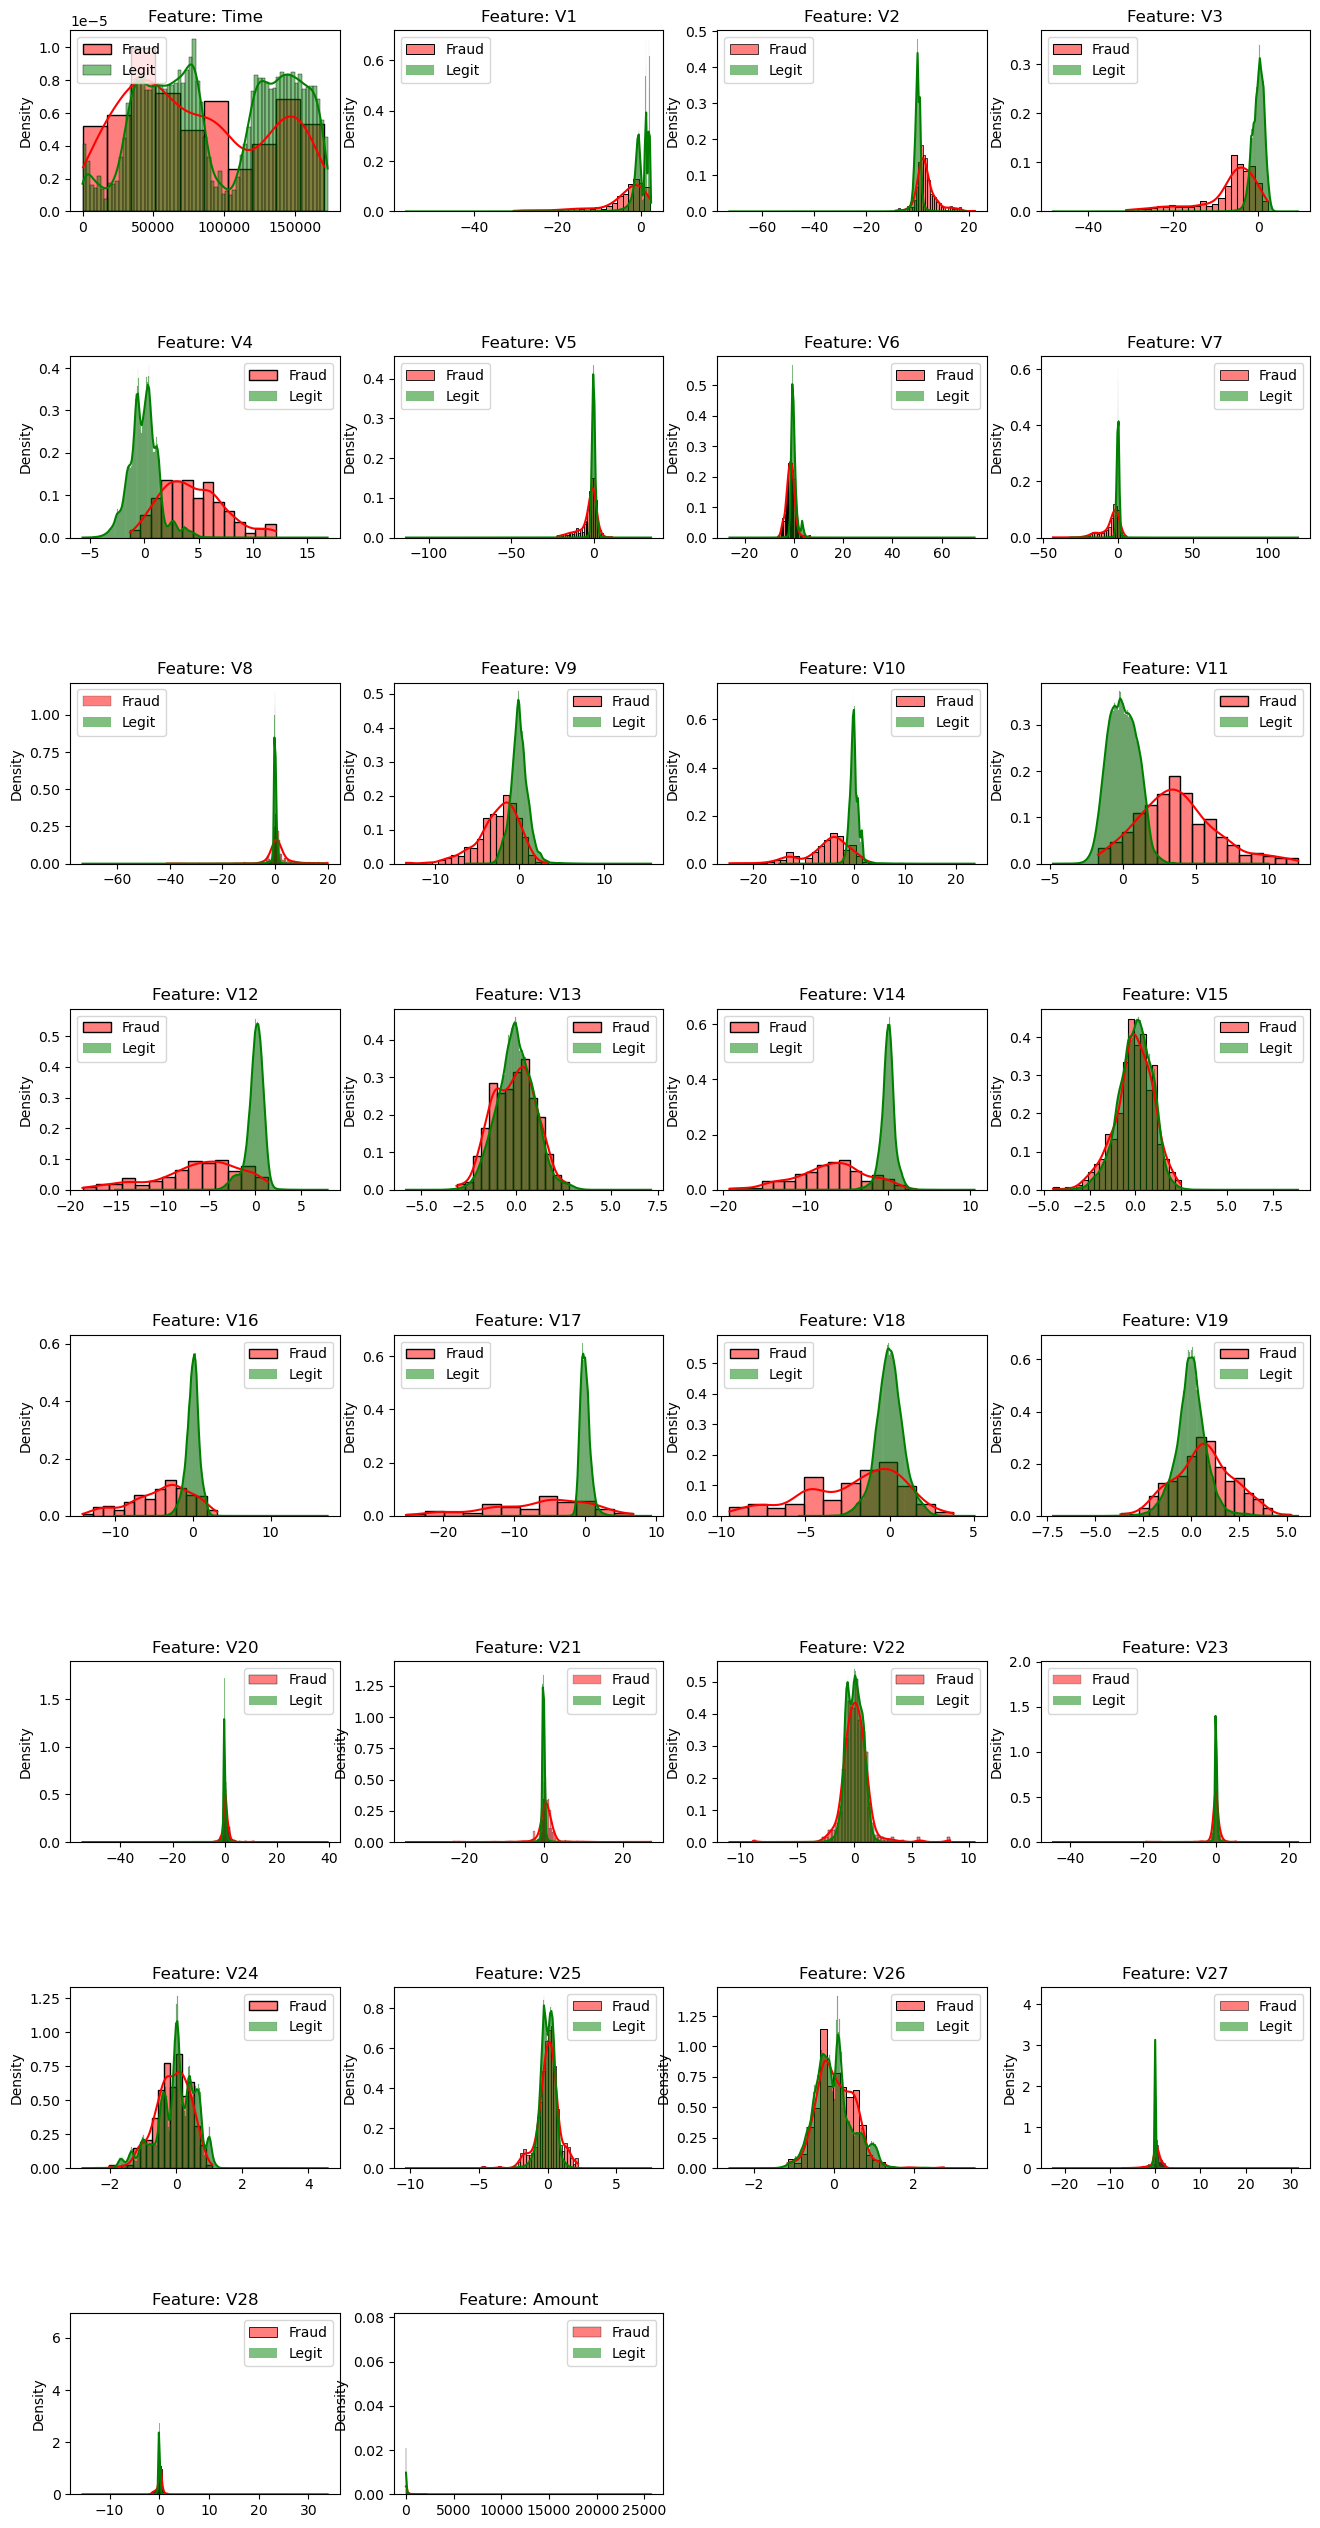

In [10]:
# Seleccionamos solamente las características
features = df.drop(columns=["Class"])

# Creamos la figura
plt.figure(figsize=(16, 32))


gs = gridspec.GridSpec(8, 4)
gs.update(hspace=0.8)

for i, f in enumerate(features):

    ax = plt.subplot(gs[i])

    # Clase 1: fraude
    sns.histplot(  data=df[df["Class"] == 1], x=f, kde=True, color="red", stat="density", label="Fraud", alpha=0.5, ax=ax)

    # Clase 0: legítima
    sns.histplot(data=df[df["Class"] == 0],x=f,  kde=True,  color="green",  stat="density",  label="Legit",  alpha=0.5, ax=ax )

    ax.set_xlabel("")
    ax.set_title(f"Feature: {f}")
    ax.legend()

plt.show()

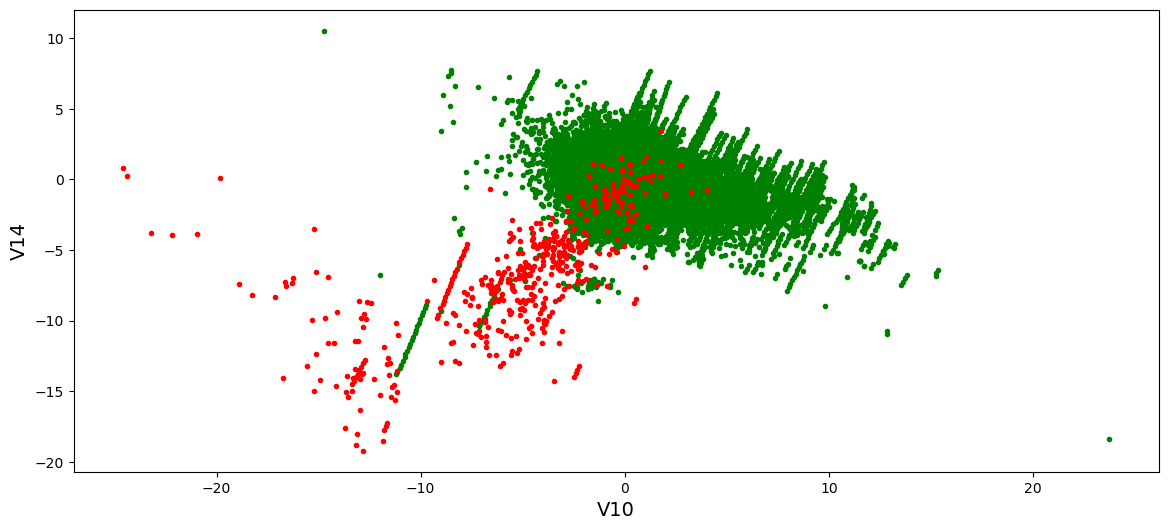

In [11]:
# Representación gráfica de dos características
plt.figure(figsize=(14, 6))
plt.scatter(df["V10"][df['Class'] == 0], df["V14"][df['Class'] == 0], c="g", marker=".")
plt.scatter(df["V10"][df['Class'] == 1], df["V14"][df['Class'] == 1], c="r", marker=".")
plt.xlabel("V10", fontsize=14)
plt.ylabel("V14", fontsize=14)
plt.show()

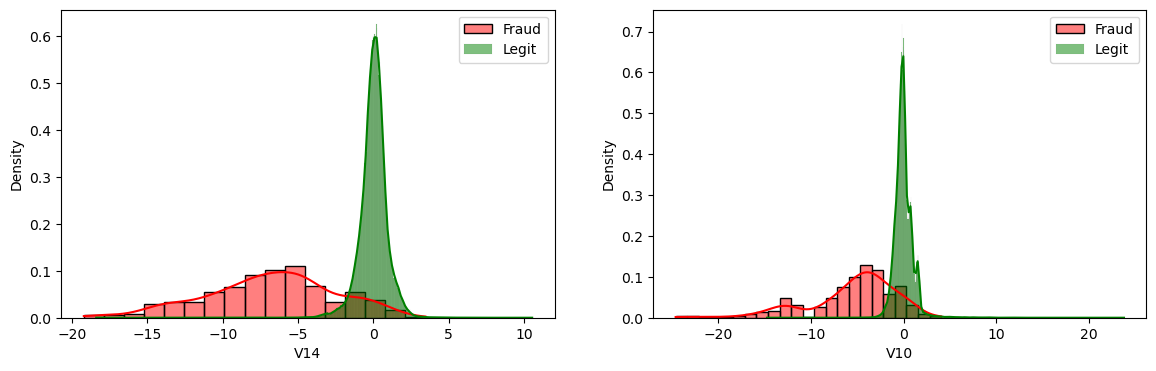

In [12]:
plt.figure(figsize=(14,4))
gs = gridspec.GridSpec(1, 2)

# Representación de la característica 1
ax = plt.subplot(gs[0])
sns.histplot(data=df[df['Class'] == 1], x="V14", kde=True, color="red", stat="density", label="Fraud", alpha=0.5)
sns.histplot(data=df[df['Class'] == 0], x="V14", kde=True, color="green", stat="density", label="Legit", alpha=0.5)
ax.legend()  # Para mostrar la leyenda

# Representación de la característica 2
ax = plt.subplot(gs[1])
sns.histplot(data=df[df['Class'] == 1], x="V10", kde=True, color="red", stat="density", label="Fraud", alpha=0.5)
sns.histplot(data=df[df['Class'] == 0], x="V10", kde=True, color="green", stat="density", label="Legit", alpha=0.5)
ax.legend()  # Para mostrar la leyenda

plt.show()

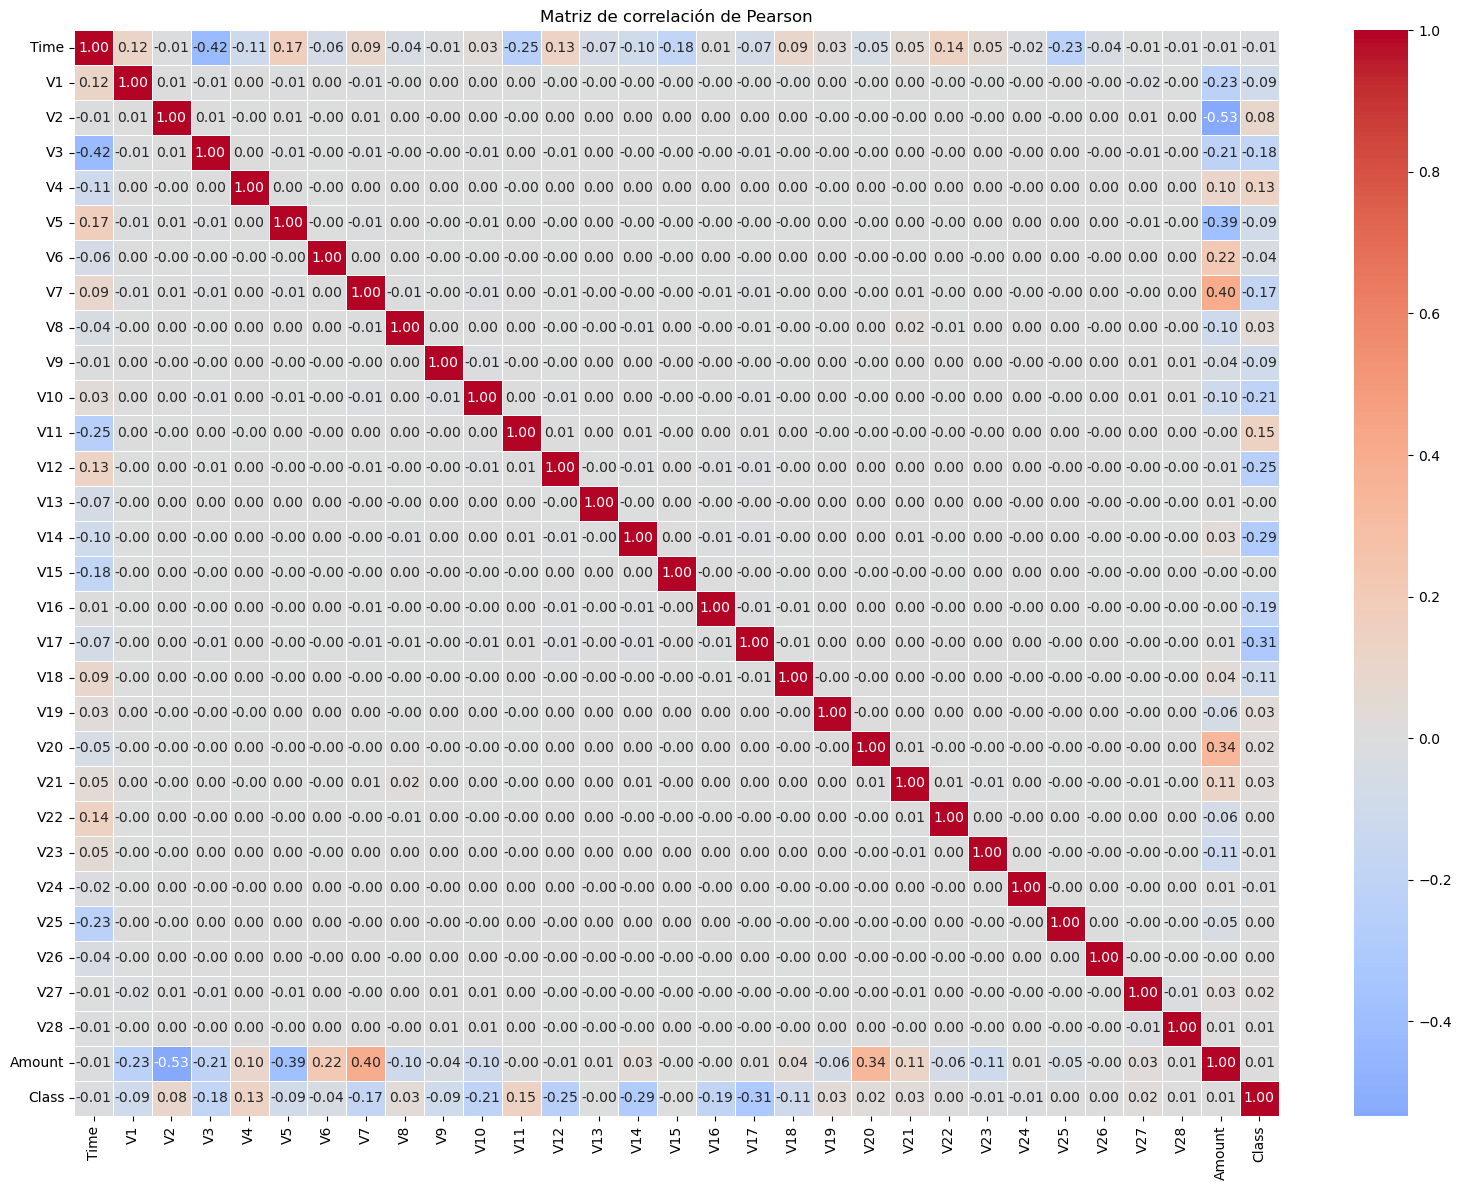

In [13]:
# Matriz de correlación de Pearson
corr = df.corr(method="pearson")

# Mostrar la matriz
plt.figure(figsize=(16, 12))

sns.heatmap(corr,cmap="coolwarm",center=0,annot=True,fmt=".2f",linewidths=0.5)

plt.title("Matriz de correlación de Pearson")
plt.tight_layout()
plt.show()

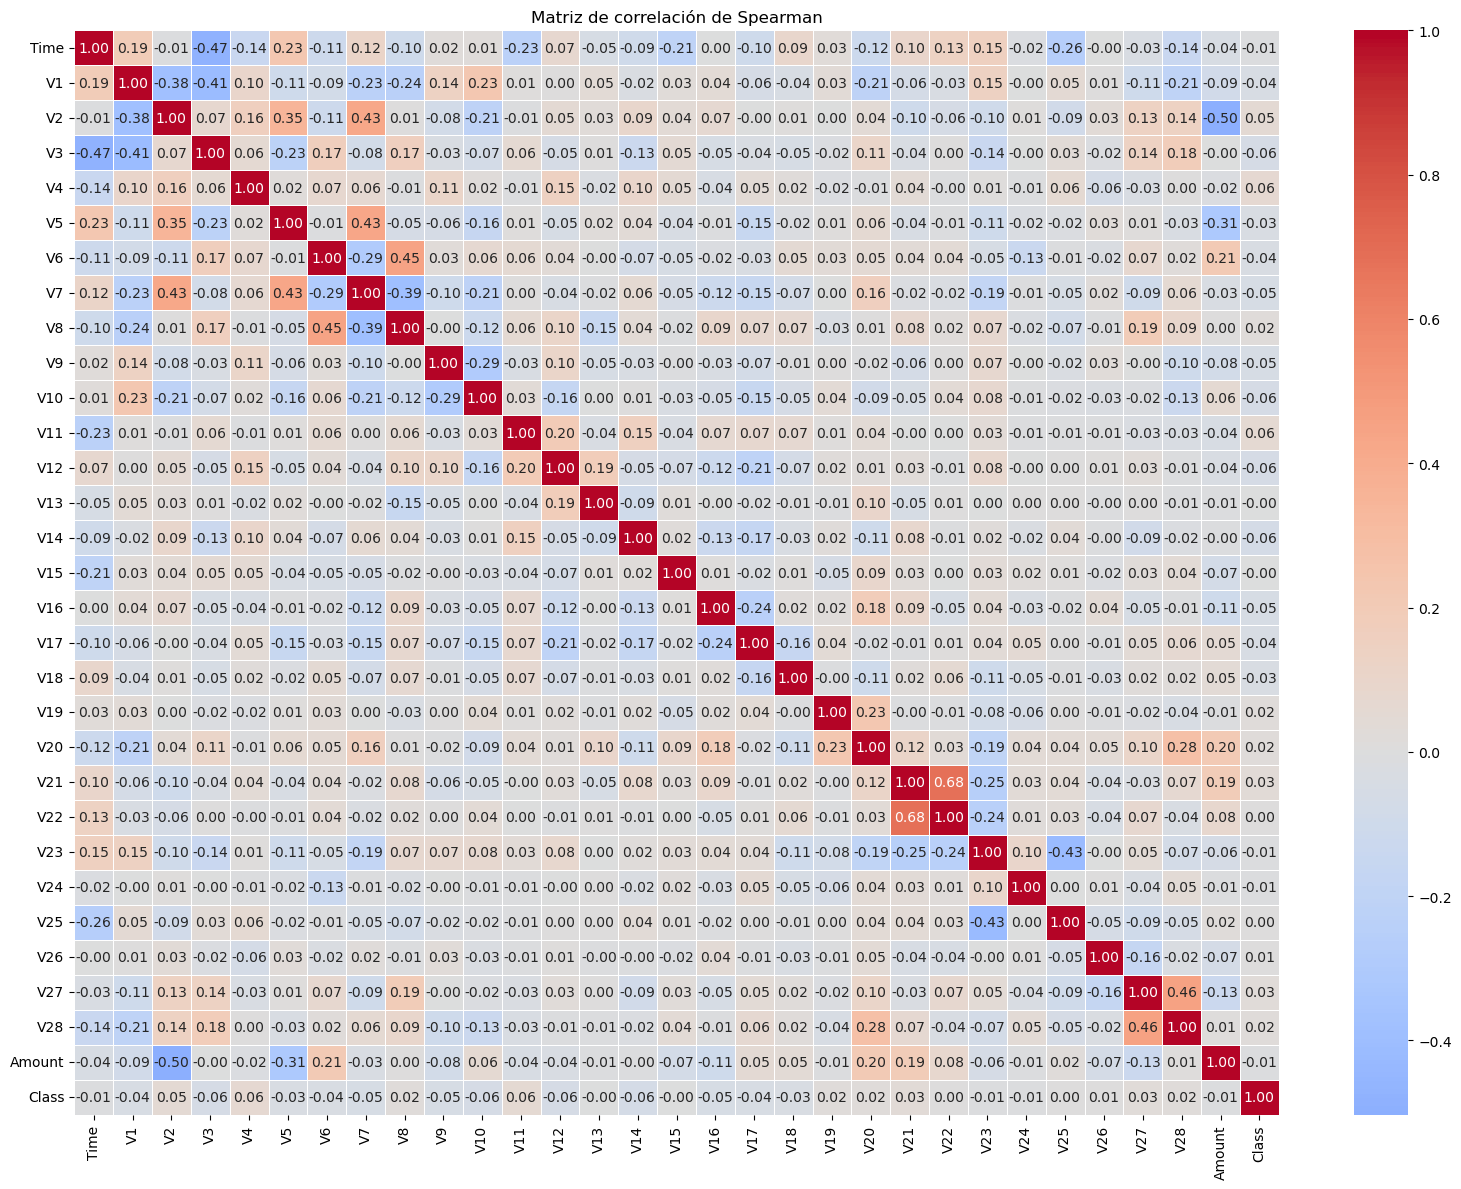

In [14]:
# Matriz de correlación de Pearson
corr = df.corr(method="spearman")

# Mostrar la matriz
plt.figure(figsize=(16, 12))

sns.heatmap(corr,cmap="coolwarm",center=0,annot=True,fmt=".2f",linewidths=0.5)

plt.title("Matriz de correlación de Spearman")
plt.tight_layout()
plt.show()

In [15]:
#sns.pairplot(df,hue = 'Class', palette= 'coolwarm')

### Desarrollo de modelos

#### Distribucion Gausiana

La distribución gaussiana (o normal) permite modelar cómo se distribuyen normalmente los valores de una variable.

Se caracteriza principalmente por:

- **Media ($\mu$)**: representa el valor promedio.
- **Desvío estándar ($\sigma$)**: indica cuánto se alejan los valores de la media.

La función de densidad es:

$$
P(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}
$$

¿Cómo se usa para detectar anomalías?

La idea es que los valores cercanos a la media son normales, mientras que los valores muy alejados son potencialmente anómalos.

Una regla sencilla es utilizar el **z-score**:

$$
z = \frac{x - \mu}{\sigma}
$$

Por ejemplo:

- $|z| < 2$ → comportamiento normal
- $2 \leq |z| < 3$ → podría ser sospechoso
- $|z| \geq 3$ → posible anomalía

Ejemplo

Supongamos que medimos la temperatura de una máquina:

- **Media**: $\mu = 70^\circ\text{C}$
- **Desvío estándar**: $\sigma = 5^\circ\text{C}$

Una medición de **72°C** tiene:

$$
z = \frac{72 - 70}{5} = 0.4
$$

Está cerca de la media, por lo que no sería una anomalía.

En cambio, una medición de **90°C**:

$$
z = \frac{90 - 70}{5} = 4
$$

Está a 4 desviaciones estándar de la media, por lo que podría considerarse anómala.

In [16]:
df_prep = df.drop(["Time", "Amount"], axis=1)

In [17]:
X = df_prep.drop("Class", axis=1)
y = df_prep["Class"].copy()

In [18]:
X_reduced = X[["V10", "V14"]].copy()

In [19]:
gm = GaussianMixture(n_components=2, random_state=42)
gm.fit(X_reduced)

GaussianMixture(n_components=2, random_state=42)

In [20]:
def plot_gaussian_mixture(clusterer, X, y, resolution=1000):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = -clusterer.score_samples(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z,
                 norm=LogNorm(vmin=1.0, vmax=30.0),
                 levels=np.logspace(0, 2, 12))
    plt.contour(xx, yy, Z,
                norm=LogNorm(vmin=1.0, vmax=30.0),
                levels=np.logspace(0, 2, 12),
                linewidths=1, colors='k')

    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], 'k.', markersize=2)
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], 'r.', markersize=2)

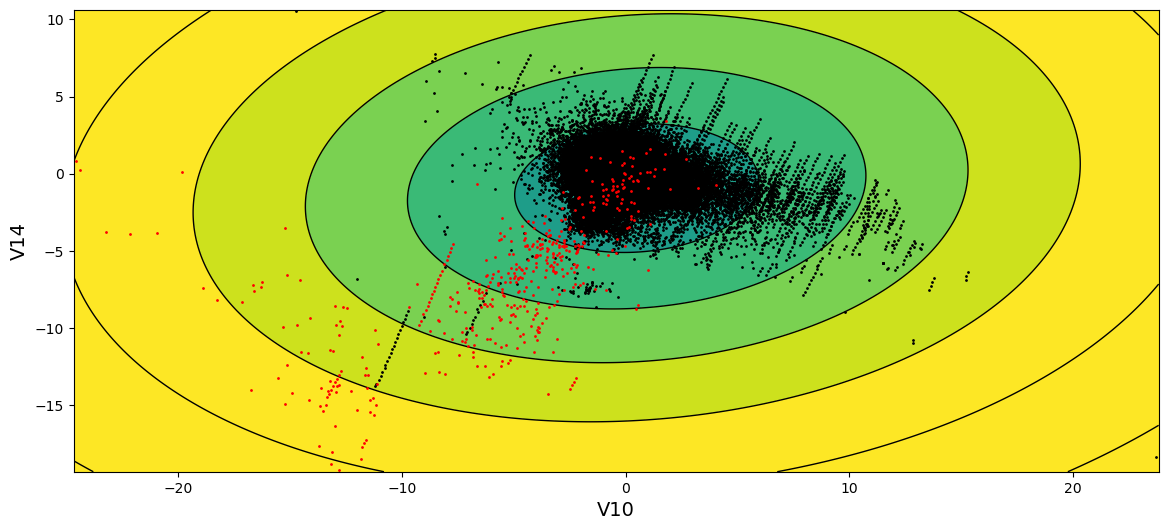

In [21]:
plt.figure(figsize=(14, 6))
plot_gaussian_mixture(gm, X_reduced.values, y)
plt.xlabel("V10", fontsize=14)
plt.ylabel("V14", fontsize=14)
plt.show()

In [22]:
# Selección del Threshold
densities = gm.score_samples(X_reduced)
density_threshold = np.percentile(densities, 0.03)
print("Threshold seleccionado:", density_threshold)



Threshold seleccionado: -23.02724678092802


Representacion de las anomalias

In [23]:
# Identificación de anomalías
anomalies = X_reduced.values[densities < density_threshold]

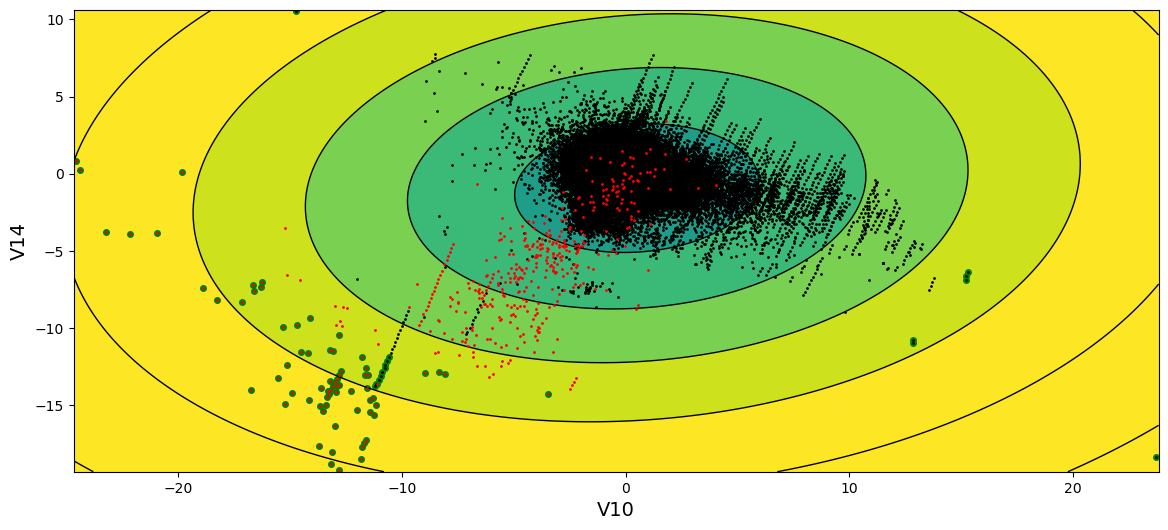

In [24]:
# Representación gráfica de las anomalías
plt.figure(figsize=(14, 6))
plt.plot(anomalies[:, 0], anomalies[:, 1], 'go', markersize=4)
plot_gaussian_mixture(gm, X_reduced.values, y)
plt.xlabel("V10", fontsize=14)
plt.ylabel("V14", fontsize=14)
plt.show()

In [25]:
# Comparación de cuantas anomalías se correspondían con ejemplos fraudulentos
y_preds = (densities < density_threshold)
y_preds[y_preds == False] = 0
y_preds[y_preds == True] = 1

In [26]:
# Clases originales
y.value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [27]:
# Casos identificados como anomalías etiquetados como negativos (0) y positivos (1)
y[y_preds==1].value_counts()

Class
1    70
0    16
Name: count, dtype: int64

###### Conjunto Multidimensional

In [28]:
# Entrenamiento del modelo
gm = GaussianMixture(n_components=2, random_state=42)
gm.fit(X)

GaussianMixture(n_components=2, random_state=42)

In [29]:
# Selección del Threshold
densities = gm.score_samples(X)
density_threshold = np.percentile(densities, 0.1)
print("Threshold seleccionado:", density_threshold)

Threshold seleccionado: -446.64781142361915


In [30]:
# Comparación de cuantas anomalías se correspondían con ejemplos fraudulentos
y_preds = (densities < -470)
y_preds[y_preds == False] = 0
y_preds[y_preds == True] = 1

In [31]:
# Casos identificados como anomalías etiquetados como negativos (0) y positivos (1)
y[y_preds==1].value_counts()

Class
1    156
0    119
Name: count, dtype: int64

In [32]:
class GaussianAnomalyDetector(BaseEstimator):
    def __init__(self, threshold=1):
        self._threshold = threshold
        self._gm = None
    def fit(self, X, y=None):
        self._gm = GaussianMixture(n_components=2, n_init=10, random_state=42)
        self._gm.fit(X) 
        return self
    
    def predict(self, X, y=None):
        densities = self._gm.score_samples(X)
        y_preds = (densities < self._threshold)
        y_preds[y_preds == False] = 0
        y_preds[y_preds == True] = 1
        return y_preds
    
    def get_params(self, deep=True):
        return {"threshold": self._threshold}

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
            return self

In [33]:
gad = GaussianAnomalyDetector()

param_distribs = {

    'threshold': uniform(loc=0.01, scale=4.99),
}

# Configuración de RandomizedSearchCV (5*3=15 rondas de entrenamiento)
rnd_search = RandomizedSearchCV(gad, param_distributions=param_distribs,
                                n_iter=5, cv=3, scoring='f1')

# Entrenamiento del modelo
rnd_search.fit(X, y)

RandomizedSearchCV(cv=3, estimator=GaussianAnomalyDetector(), n_iter=5,
                   param_distributions={'threshold': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001D002D0C2F0>},
                   scoring='f1')

In [34]:
cvres = rnd_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(mean_score, params)



0.005718109172363761 {'threshold': 0.6954915230524059}
0.005718109172363761 {'threshold': 3.111518135300457}
0.005718109172363761 {'threshold': 4.124549634350371}
0.005718109172363761 {'threshold': 0.3712335010513556}
0.005718109172363761 {'threshold': 3.704031107930157}


In [35]:
def select_threshold(list_thds, densities, y):
    best_prec = 0
    best_threshold = 0
    i = 0
    for thd in list_thds:
        i += 1
        print("\rSearching best threshold {0}%".format(
            int((i + 1) / len(list_thds) * 100)), end='')
        preds = (densities < thd)
        preds[preds == False] = 0
        preds[preds == True] = 1
        precision = precision_score(y, preds)
        if precision > best_prec:
            best_prec = precision
            best_threshold = thd
    return (best_prec, best_threshold)

In [36]:
select_threshold(np.arange(-600, -300, 1), densities, y)

Searching best threshold 0%

Searching best threshold 100%

(0.6211453744493393, -600)

#### Isolation Forest

Isolation Forest es un algoritmo de Machine Learning utilizado para detectar anomalías o valores atípicos (outliers) en un conjunto de datos.

La idea principal es que las anomalías suelen ser pocos datos y diferentes al resto, por lo que son más fáciles de aislar.
¿Cómo funciona?

Isolation Forest construye muchos árboles de decisión de forma aleatoria.

En cada árbol:

1) Se selecciona una variable al azar.

2)    Se selecciona un punto de corte aleatorio.

3)    Los datos se van dividiendo en diferentes grupos.

4)    El proceso continúa hasta que los puntos quedan aislados.

Los puntos que necesitan pocas divisiones para quedar aislados tienen más probabilidades de ser anomalías.

Ejemplo

Supongamos que tenemos temperaturas normales de una máquina:

68, 70, 71, 72, 69, 70, 71, 73, 72, 95

La mayoría de los valores están alrededor de 70°C, mientras que 95°C está muy alejado.

Un Isolation Forest probablemente aislará rápidamente el valor 95, ya que necesita pocas divisiones para separarlo del resto.

Por lo tanto:

68  → Normal <br>
70  → Normal <br>
71  → Normal <br>
72  → Normal <br>
69  → Normal <br>
70  → Normal <br>
71  → Normal <br>
73  → Normal <br>
72  → Normal <br>
95  → Anomalía <br>
¿Por qué funciona? <br>

Las anomalías suelen tener características particulares:

Son poco frecuentes.
Están alejadas de la mayoría de los datos.
Son más fáciles de separar mediante divisiones aleatorias.

Por eso, cuanto menor sea la cantidad de divisiones necesarias para aislar un punto, mayor es la probabilidad de que sea una anomalía.

In [37]:
df_prep = df.drop(["Time", "Amount"], axis=1)

In [38]:
X = df_prep.drop("Class", axis=1)
y = df_prep["Class"].copy()

In [39]:
X_reduced = X[["V10", "V14"]].copy()

In [40]:
ift_clf = IsolationForest(contamination=0.01, max_samples=300)
ift_clf.fit(X_reduced)

IsolationForest(contamination=0.01, max_samples=300)

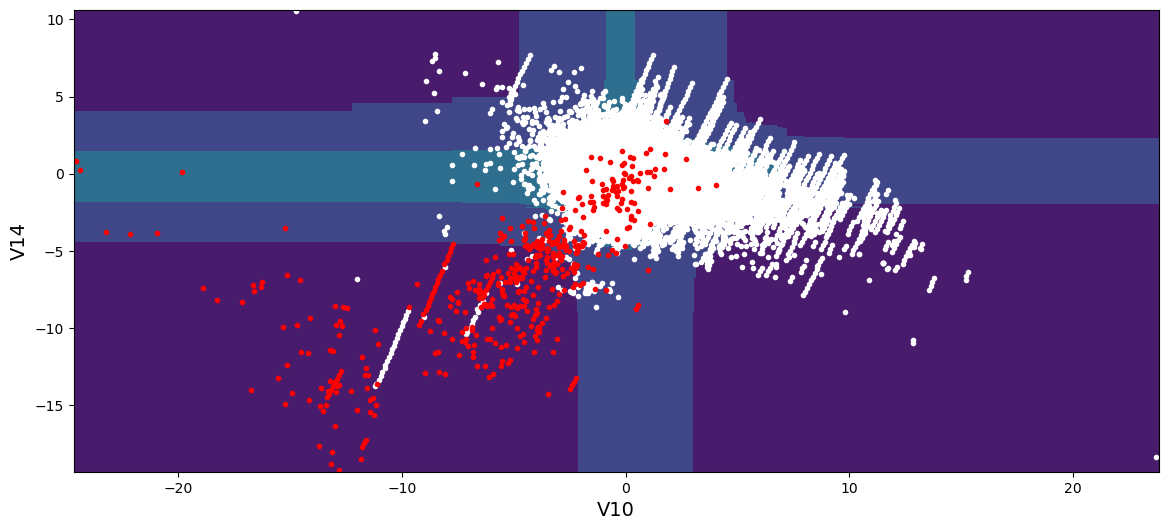

In [41]:
def plot_isolation_forest(X, y, resolution=1000):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    
    Z = ift_clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z)

    plt.plot(X[:, 0][y==0], X[:, 1][y==0], 'w.')
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], 'r.')
    
plt.figure(figsize=(14, 6))
plot_isolation_forest(X_reduced.values, y)
plt.xlabel("V10", fontsize=14)
plt.ylabel("V14", fontsize=14)
plt.show()

###### Detencion de anomalias

In [42]:
# Identificación de anomalías
anomalies = ift_clf.predict(X_reduced)

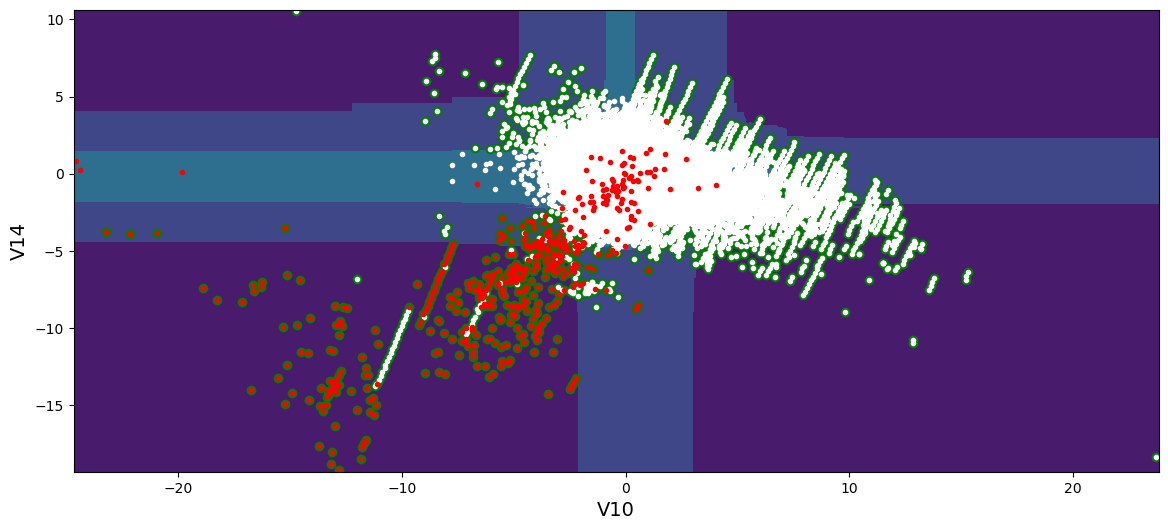

In [43]:
# Representación gráfica de las anomalías
plt.figure(figsize=(14, 6))
plt.plot(X_reduced["V10"][anomalies == -1], X_reduced["V14"][anomalies == -1], 'go', markersize=6)
plot_isolation_forest(X_reduced.values, y)
plt.xlabel("V10", fontsize=14)
plt.ylabel("V14", fontsize=14)
plt.show()

In [44]:
print("Total de anomalías identificadas:", len(y[anomalies==-1]))

Total de anomalías identificadas: 2837


In [45]:
# Verdaderos y falsos positivos de casos fraudulentos en el total de anomalías
y[anomalies==-1].value_counts()

Class
0    2452
1     385
Name: count, dtype: int64

###### Detencion de Anomalias

In [46]:
ift_clf = IsolationForest(max_samples=100, contamination=0.015)
ift_clf.fit(X)

IsolationForest(contamination=0.015, max_samples=100)

In [47]:
# Identificación de anomalías
anomalies = ift_clf.predict(X)

In [48]:
print("Total de anomalías identificadas:", len(y[anomalies==-1]))

Total de anomalías identificadas: 4256


In [49]:
# Verdaderos y falsos positivos de casos fraudulentos
y[anomalies==-1].value_counts()

Class
0    3907
1     349
Name: count, dtype: int64

In [50]:
# Creamos nuestro propio estimador para que la salida del algoritmo este comprendida entre 0 y 1
class IsolationForestCustom(BaseEstimator):
    def __init__(self, max_samples=100, contamination=0.1):
        self.contamination = contamination
        self.max_samples = max_samples
        self._ift_clf = None
        
    def fit(self, X, y=None):
        self._ift_clf = IsolationForest(max_samples=self.max_samples, 
                                        contamination=self.contamination)
        self._ift_clf.fit(X) 
        return self
    
    def predict(self, X, y=None):
        preds = self._ift_clf.predict(X)
        preds[preds==1] = 0
        preds[preds==-1] = 1
        return preds
    
    def get_params(self, deep=True):
        return {"contamination": self.contamination,
               "max_samples": self.max_samples}

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self

In [51]:
param_grid = {'max_samples': [100, 200, 300], 'contamination': [0.001, 0.01, 0.1]}

ift_clf = IsolationForestCustom()

# train across 5 folds, that's a total of 6*2=12 rounds of training 
grid_search = GridSearchCV(ift_clf, param_grid, cv=2,
                           scoring='f1', return_train_score=True)

grid_search.fit(X_reduced, y)

GridSearchCV(cv=2, estimator=IsolationForestCustom(),
             param_grid={'contamination': [0.001, 0.01, 0.1],
                         'max_samples': [100, 200, 300]},
             return_train_score=True, scoring='f1')

In [52]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(mean_score, params)

0.0 {'contamination': 0.001, 'max_samples': 100}
0.0 {'contamination': 0.001, 'max_samples': 200}
0.24259127548601234 {'contamination': 0.001, 'max_samples': 300}
0.22993929981114475 {'contamination': 0.01, 'max_samples': 100}
0.2323129983883177 {'contamination': 0.01, 'max_samples': 200}
0.23069050832208726 {'contamination': 0.01, 'max_samples': 300}
0.030224266063571217 {'contamination': 0.1, 'max_samples': 100}
0.030478576511200645 {'contamination': 0.1, 'max_samples': 200}
0.02967854573361304 {'contamination': 0.1, 'max_samples': 300}


In [53]:
grid_search.best_estimator_

IsolationForestCustom(contamination=0.001, max_samples=300)

#### Redes Neuronales (Multi Layer Perceptron)

Un **MLP (Multi-Layer Perceptron)** es una red neuronal artificial que puede utilizarse para detectar anomalías aprendiendo los patrones presentes en los datos.

Un MLP está compuesto por diferentes tipos de capas:

- **Capa de entrada**: recibe las variables del dato.
- **Capas ocultas**: aprenden relaciones y patrones complejos.
- **Capa de salida**: produce una predicción o un valor utilizado para detectar la anomalía.

Una estrategia común es entrenar el MLP para aprender a reconstruir los datos normales.

El modelo recibe un dato:

Entrada → MLP → Reconstrucción

Luego se compara el dato original con el dato reconstruido.

Si el error de reconstrucción es pequeño, el dato probablemente sea normal.
Si el error es grande, puede tratarse de una anomalía.
Ejemplo

Supongamos que tenemos datos de sensores de una máquina:

Temperatura = 70°C
Presión     = 100 bar
Vibración   = 0.2

El MLP aprende cómo suelen comportarse estos valores cuando la máquina funciona normalmente.

Para un dato normal:

Dato original       → [70, 100, 0.2]
Dato reconstruido   → [69,  99, 0.2]

Error → Bajo → Normal

Pero ante un comportamiento anómalo:

Dato original       → [95, 130, 2.5]
Dato reconstruido   → [72, 102, 0.3]

Error → Alto → 🚨 Anomalía
Error de reconstrucción

Podemos calcular el error utilizando, por ejemplo, el Mean Squared Error (MSE):

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(x_i-\hat{x}_i)^2
$$

Donde:

$x_i$ es el valor original.
$\hat{x}_i$ es el valor reconstruido por la red.
$n$ es la cantidad de variables.

Después establecemos un umbral:

Error < umbral  → Normal
Error ≥ umbral  → 🚨 Anomalía
¿Qué aprende el MLP?

Durante el entrenamiento, el MLP aprende las relaciones y patrones presentes en los datos normales.

Por ejemplo, puede aprender que:

Cuando la temperatura aumenta, la vibración normalmente también aumenta de determinada manera.

Si aparece una combinación de valores que no se parece a lo aprendido, la red tendrá más dificultades para reconstruirla y el error será mayor.

Ventajas
Puede aprender relaciones no lineales.
Puede trabajar con múltiples variables al mismo tiempo.
No requiere asumir que los datos siguen una distribución gaussiana.
Puede detectar anomalías más complejas que un simple método basado en distancia.

In [54]:
#Funcion para dividir el conjunto de datos en 3 funciones, construcción de una función que realice el particionado completo
def train_val_test_split(df, rstate=42, shuffle=True, stratify=None):
    strat = df[stratify] if stratify else None
    train_set, test_set = train_test_split(
        df, test_size=0.4, random_state=rstate, shuffle=shuffle, stratify=strat)
    strat = test_set[stratify] if stratify else None
    val_set, test_set = train_test_split(
        test_set, test_size=0.5, random_state=rstate, shuffle=shuffle, stratify=strat)
    return (train_set, val_set, test_set)


def remove_labels(df, label_name):
    X = df.drop(label_name, axis=1)
    y = df[label_name].copy()
    return (X, y)

In [55]:
df = df.drop(["Time", "Amount"], axis=1)

In [56]:
train_set, val_set, test_set = train_val_test_split(df)

In [57]:
X_train, y_train = remove_labels(train_set, 'Class')
X_val, y_val = remove_labels(val_set, 'Class')
X_test, y_test = remove_labels(test_set, 'Class')

In [58]:
X_train_reduced = X_train[["V10", "V14"]].copy()
X_val_reduced = X_val[["V10", "V14"]].copy()
X_test_reduced = X_test[["V10", "V14"]].copy()

In [59]:
X_train_reduced

,V10,V14
191467,1.064512,0.208293
199194,0.904934,-0.877155
230398,-0.685730,0.695345
141347,-0.682162,0.085231
126180,-1.014186,0.318859
...,...,...
120348,0.274674,0.471236
260136,-0.664895,-0.865914
132427,0.094031,0.251526
147428,0.008851,0.096902


In [60]:
model = models.Sequential()
model.add(layers.Dense(128, activation='relu', input_shape=(X_train_reduced.shape[1],)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',  loss='binary_crossentropy', metrics=['acc'])

In [61]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,265 (44.00 KB)

 Trainable params: 11,265 (44.00 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
# Entrenamiento del modelo

history = model.fit(X_train_reduced,y_train, epochs=50,batch_size=512, validation_data=(X_val_reduced, y_val))

Epoch 1/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - acc: 0.9792 - loss: 0.1314 - val_acc: 0.9993 - val_loss: 0.0040
Epoch 2/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - acc: 0.9992 - loss: 0.0043 - val_acc: 0.9994 - val_loss: 0.0037
Epoch 3/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - acc: 0.9991 - loss: 0.0041 - val_acc: 0.9992 - val_loss: 0.0035
Epoch 4/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - acc: 0.9992 - loss: 0.0035 - val_acc: 0.9993 - val_loss: 0.0034
Epoch 5/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - acc: 0.9993 - loss: 0.0037 - val_acc: 0.9993 - val_loss: 0.0034
Epoch 6/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - acc: 0.9991 - loss: 0.0044 - val_acc: 0.9993 - val_loss: 0.0034
Epoch 7/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - acc: 0.9993 - loss: 0.0035 - val_acc: 0.9993 - val_loss: 0.0033
Epoch 8/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - acc: 0.9993 - loss: 0.0038 - val_acc: 0.9994 - val_loss: 0.0033
Epoch 9/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - a

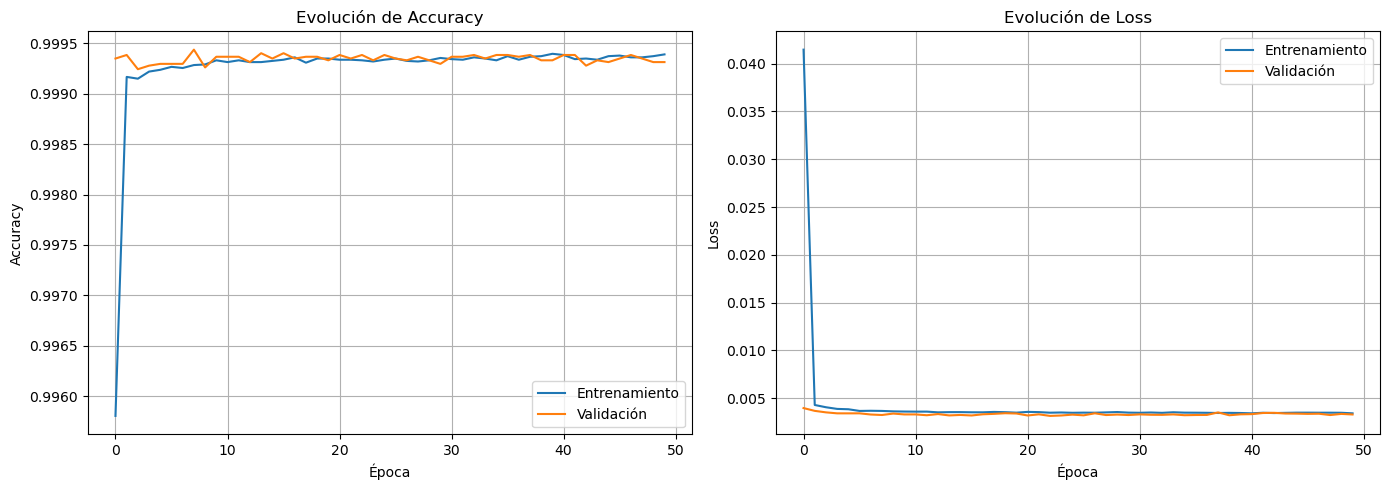

In [63]:
plt.figure(figsize=(14, 5))


# Accuracy

plt.subplot(1, 2, 1)

plt.plot(history.history['acc'], label='Entrenamiento')

plt.plot(history.history['val_acc'], label='Validación')

plt.title('Evolución de Accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)


plt.subplot(1, 2, 2)

plt.plot(history.history['loss'],label='Entrenamiento')

plt.plot( history.history['val_loss'], label='Validación')

plt.title('Evolución de Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Representacion del limite de la decision

31250/31250 ━━━━━━━━━━━━━━━━━━━━ 63s 2ms/step


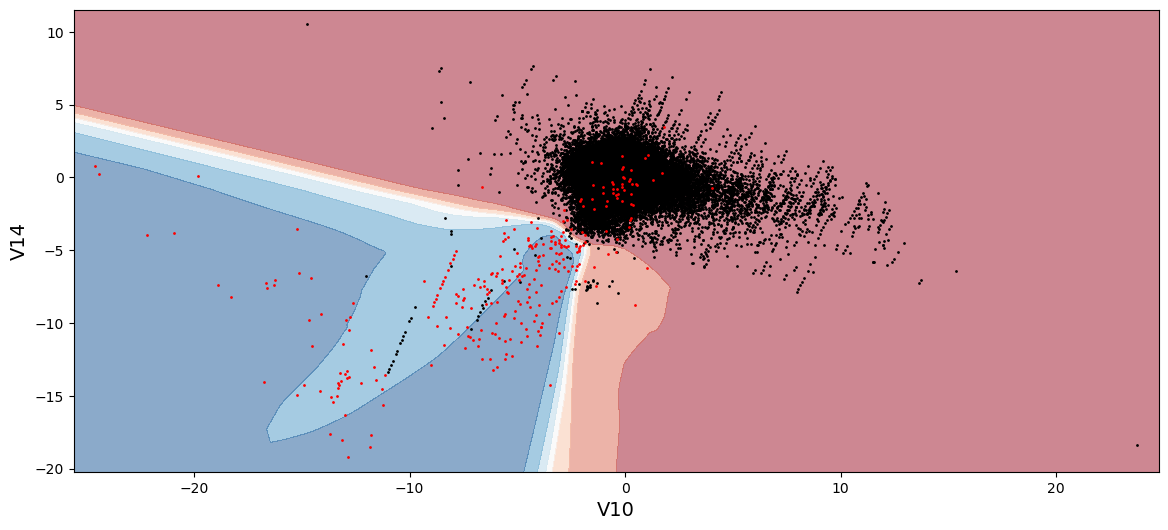

In [64]:
def plot_ann_decision_boundary(X, y, model, steps=1000):
    xmin, xmax = X[:,0].min() - 1, X[:,0].max() + 1
    ymin, ymax = X[:,1].min() - 1, X[:,1].max() + 1
    steps = 1000
    
    x_span = np.linspace(xmin, xmax, steps)
    y_span = np.linspace(ymin, ymax, steps)
    xx, yy = np.meshgrid(x_span, y_span)

    labels = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = labels.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, cmap="RdBu", alpha=0.5)
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], 'k.', markersize=2)
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], 'r.', markersize=2)


plt.figure(figsize=(14, 6))
plot_ann_decision_boundary(X_train_reduced.values,y_train, model)
plt.xlabel("V10", fontsize=14)
plt.ylabel("V14", fontsize=14)
plt.show()

Representacion de ejemplos catalogados como maliciosos

In [65]:
# Predicción con el conjunto de datos de entrenamiento
pred = model.predict(X_train_reduced) 
y_pred = (pred > 0.5).astype("int32")

5320/5320 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step


31250/31250 ━━━━━━━━━━━━━━━━━━━━ 75s 2ms/step


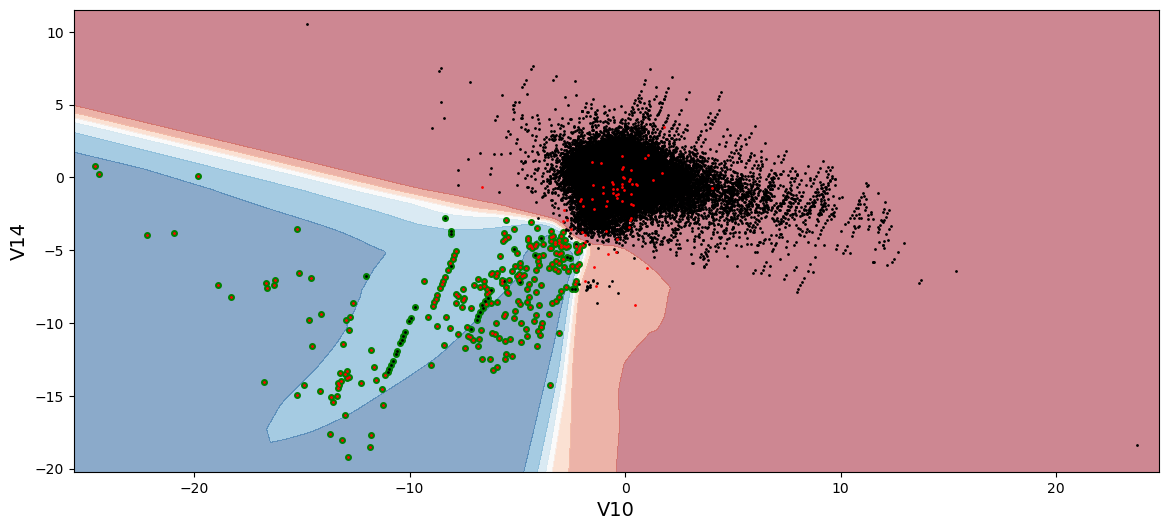

In [66]:
plt.figure(figsize=(14, 6))
plt.plot(X_train_reduced[y_pred==1]["V10"], X_train_reduced[y_pred==1]["V14"], 'go', markersize=4)
plot_ann_decision_boundary(X_train_reduced.values, y_train, model)
plt.xlabel("V10", fontsize=14)
plt.ylabel("V14", fontsize=14)
plt.show()

Prediccion de un conjunto de datos reducidos

In [67]:
# Predicción con el conjunto de datos de pruebas
pred = model.predict(X_test_reduced) 
y_pred = (pred > 0.5).astype("int32")

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


In [68]:
print("F1 Score:", f1_score(y_test, y_pred))

F1 Score: 0.7934782608695652


In [69]:
clf_rnd = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
clf_rnd.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50, n_jobs=-1, random_state=42)

In [70]:
# Seleccionamos las características más importantes
feature_importances = {name: score for name, score in zip(list(X_train), clf_rnd.feature_importances_)}
feature_importances_sorted = pd.Series(feature_importances).sort_values(ascending=False)
feature_importances_sorted.head(10)

V17    0.216185
V14    0.157680
V12    0.076775
V10    0.069451
V16    0.062393
V11    0.057038
V18    0.046371
V9     0.028303
V7     0.026566
V4     0.021604
dtype: float64

In [71]:
# Reducimos el conjunto de datos a las 20 características más importantes
features = list(feature_importances_sorted.head(20).index)
X_train_select = X_train[features].copy()
X_val_select = X_val[features].copy()
X_test_select = X_test[features].copy()
X_train_select

,V17,V14,V12,V10,V16,V11,V18,V9,V7,V4,V26,V6,V3,V20,V1,V22,V21,V15,V19,V8
191467,0.282266,0.208293,-0.149989,1.064512,0.049653,-1.324377,-0.317516,-2.339512,0.430449,4.232087,-0.030670,1.279338,1.495835,0.460570,-0.835532,-1.418143,-0.461776,0.448916,1.662293,0.626250
199194,0.339659,-0.877155,-0.282645,0.904934,-0.541420,-0.979979,-0.082658,-1.946720,-0.463036,-2.454486,-0.252451,-0.643284,0.697582,-0.501815,0.146754,0.089232,0.688565,-0.747595,-0.410785,-1.038245
230398,-0.015131,0.695345,0.260579,-0.685730,-0.881649,0.984838,0.224196,-0.870293,4.754972,-0.068123,-0.162398,1.741735,-1.476439,-1.055273,-2.057841,0.763457,-0.171125,-0.081752,1.608790,-0.835762
141347,0.815400,0.085231,0.060651,-0.682162,-0.551074,-0.575914,-0.377518,0.153052,-0.629966,0.849393,0.505024,0.062755,2.046276,-0.019079,-0.861279,0.350045,0.129192,0.786202,0.629997,0.738589
126180,0.102344,0.318859,-0.348620,-1.014186,-0.431997,-0.530677,0.357545,2.139948,-0.718350,-0.626600,-0.699251,-1.065344,1.000396,-0.280567,1.222233,0.089962,-0.016790,1.495333,0.448298,0.073763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120348,0.241891,0.471236,-0.938393,0.274674,-1.473155,-1.420705,1.108092,-0.642671,0.786109,0.136170,1.038062,-0.517792,-1.083455,1.137602,-0.188193,-1.341362,0.011795,0.258192,-0.535007,-0.401554
260136,-0.085010,-0.865914,0.425067,-0.664895,0.682804,0.533995,0.447547,-0.279204,0.861209,-0.788264,0.128193,-0.203064,-0.605170,0.045101,0.149260,-0.816542,-0.326673,-0.907268,0.265041,0.067349
132427,-1.112076,0.251526,0.014542,0.094031,0.769332,-0.210105,0.635054,0.128685,-0.821682,0.071903,-0.275199,3.635628,-0.721776,-0.003257,1.259310,0.104264,0.070189,1.393660,-0.252062,0.929256
147428,-0.175583,0.096902,0.900262,0.008851,-0.354474,-0.640414,-1.075764,0.454594,0.306983,0.472515,0.272711,-1.080473,-1.161183,-0.110161,1.982903,-0.472417,-0.212230,-0.261317,0.117212,-0.373167


###### Entrenamiento de la RNA

In [72]:
# Entrenamiento del algoritmo
model = models.Sequential()

model = models.Sequential()
model.add(layers.Dense(128, activation='relu', input_shape=(X_train_select.shape[1],)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['acc'])

In [73]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,569 (53.00 KB)

 Trainable params: 13,569 (53.00 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
# Entrenamos el algoritmo
history = model.fit(X_train_select, y_train,epochs=10,batch_size=64,validation_data=(X_val_select, y_val))

Epoch 1/10
2660/2660 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - acc: 0.9916 - loss: 0.0292 - val_acc: 0.9995 - val_loss: 0.0034
Epoch 2/10
2660/2660 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - acc: 0.9992 - loss: 0.0034 - val_acc: 0.9994 - val_loss: 0.0034
Epoch 3/10
2660/2660 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - acc: 0.9994 - loss: 0.0032 - val_acc: 0.9995 - val_loss: 0.0033
Epoch 4/10
2660/2660 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - acc: 0.9994 - loss: 0.0028 - val_acc: 0.9994 - val_loss: 0.0034
Epoch 5/10
2660/2660 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - acc: 0.9994 - loss: 0.0026 - val_acc: 0.9994 - val_loss: 0.0032
Epoch 6/10
2660/2660 ━━━━━━━━━━━━━━━━━━━━ 16s 6ms/step - acc: 0.9994 - loss: 0.0027 - val_acc: 0.9994 - val_loss: 0.0031
Epoch 7/10
2660/2660 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - acc: 0.9995 - loss: 0.0025 - val_acc: 0.9994 - val_loss: 0.0033
Epoch 8/10
2660/2660 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - acc: 0.9994 - loss: 0.0020 - val_acc: 0.9994 - val_loss: 0.0034
Epoch 9/10
2660/2660 ━━━━━━━━━━━

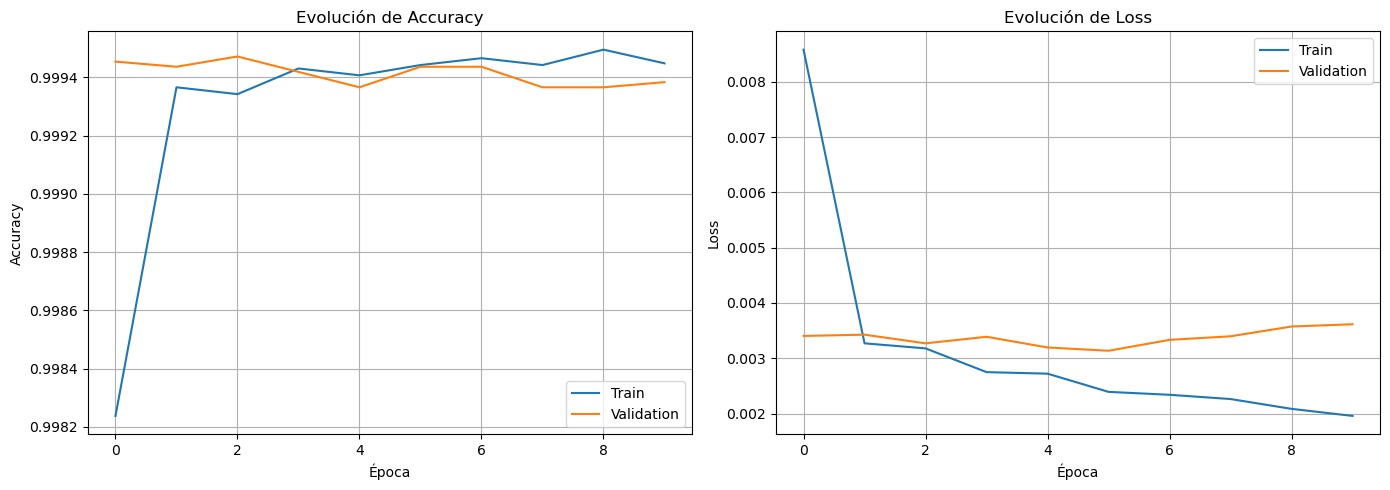

In [75]:
# Detectar automáticamente el nombre de accuracy
if 'accuracy' in history.history:
    acc = 'accuracy'
    val_acc = 'val_accuracy'
else:
    acc = 'acc'
    val_acc = 'val_acc'

plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history[acc], label='Train')
plt.plot(history.history[val_acc], label='Validation')
plt.title('Evolución de Accuracy')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Evolución de Loss')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [76]:
# Predicción con el conjunto de datos de pruebas
pred = model.predict(X_test_select) 
y_pred = (pred > 0.5).astype("int32")

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step


In [77]:
print("F1 Score:", f1_score(y_test, y_pred))

F1 Score: 0.8586956521739131


### Seleccion de Mejor Modelo

 Característica | Distribución Gaussiana | Isolation Forest | MLP (Red Neuronal) |
| :--- | :--- | :--- | :--- |
| **Tipo** | Método estadístico | Machine Learning (Árboles) | Red Neuronal Artificial |
| **Principio** | Detecta valores alejados de la media | Aísla puntos diferentes mediante particiones aleatorias | Aprende patrones de los datos (ej. reconstrucción) |
| **Asume distribución** | Sí, aproximadamente normal | No | No |
| **Relaciones no lineales** | Limitadas | Sí | Sí, muy buenas |
| **Complejidad** | Baja | Baja / Media | Media / Alta |
| **Cantidad de datos necesaria** | Baja | Baja / Media | Generalmente alta |
| **Interpretabilidad** | Alta | Media / Alta | Baja (modelo de "caja negra") |
| **Tiempo de entrenamiento** | Muy bajo | Bajo | Mayor |
| **Escalado de variables** | Generalmente importante | Poco importante | Importante |
| **Patrones complejos** | Limitados | Buenos | Muy buenos |

Resumen rápido de uso:
- **Distribución Gaussiana**: Ideal para problemas simples, univariados o cuando se necesita máxima interpretabilidad y los datos son bien comportados.
- **Isolation Forest**: Excelente opción *baseline* (línea base) para datos tabulares, multivariados y con relaciones no lineales, sin necesidad de escalar variables ni asumir distribuciones.
- **MLP**: Recomendado cuando hay grandes volúmenes de datos, relaciones no lineales muy complejas entre múltiples variables y se dispone de recursos computacionales para el entrenamiento.

In [78]:
selected_features = list(X_train_select.columns)
all_features = list(X_train.columns)

# `model` debe ser la última red entrenada (la de 20 variables)
assert model.input_shape[-1] == len(selected_features), (
    "La variable `model` no es la red de 20 variables. Ejecutá de nuevo la sección de RNA completa.")


def best_f1_threshold(y_true, scores):
    # Umbral que maximiza el F1 (score alto = más sospechoso de fraude)
    prec, rec, thr = precision_recall_curve(y_true, scores)
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-12)
    return thr[np.argmax(f1)]



gm_cmp = GaussianMixture(n_components=2, n_init=3, random_state=42).fit(X_train)
if_cmp = IsolationForest(n_estimators=100, max_samples=100, random_state=42).fit(X_train)

# Cada candidato: modelo, variables que usa y función que devuelve el puntaje de fraude
candidates = {
    "Gaussian Mixture": {
        "type": "sklearn", "model": gm_cmp, "features": all_features,
        "score_fn": lambda m, X: -m.score_samples(X),        # -log densidad
    },
    "Isolation Forest": {
        "type": "sklearn", "model": if_cmp, "features": all_features,
        "score_fn": lambda m, X: -m.score_samples(X),        # más alto = más aislado
    },
    "Red Neuronal (MLP)": {
        "type": "keras", "model": model, "features": selected_features,
        "score_fn": lambda m, X: np.asarray(m.predict(X, verbose=0)).ravel(),  # probabilidad de fraude
    },
}

X_val_full, X_test_full = X_val, X_test
rows = {}
for name, c in candidates.items():
    f = c["features"]
    s_val = c["score_fn"](c["model"], X_val_full[f])
    s_test = c["score_fn"](c["model"], X_test_full[f])
    thr = best_f1_threshold(y_val, s_val)
    y_hat = (s_test >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_hat).ravel()

    c.update(scores_test=s_test, threshold=float(thr), y_hat=y_hat, cm=np.array([[tn, fp], [fn, tp]]))
    rows[name] = {
        "Precision": precision_score(y_test, y_hat, zero_division=0),
        "Recall": recall_score(y_test, y_hat),
        "F1": f1_score(y_test, y_hat),
        "PR-AUC": average_precision_score(y_test, s_test),
        "ROC-AUC": roc_auc_score(y_test, s_test),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }

results = pd.DataFrame(rows).T
results[["TP", "FP", "FN", "TN"]] = results[["TP", "FP", "FN", "TN"]].astype(int)
print(f"Transacciones en test: {len(y_test):,} | fraudes en test: {int(y_test.sum())}")
display(results.round(4))


Transacciones en test: 56,746 | fraudes en test: 97


,Precision,Recall,F1,PR-AUC,ROC-AUC,TP,FP,FN,TN
Gaussian Mixture,0.4333,0.1340,0.2047,0.1467,0.9369,13,17,84,56632
Isolation Forest,0.3562,0.2680,0.3059,0.2194,0.9505,26,47,71,56602
Red Neuronal (MLP),0.9080,0.8144,0.8587,0.8559,0.9764,79,8,18,56641


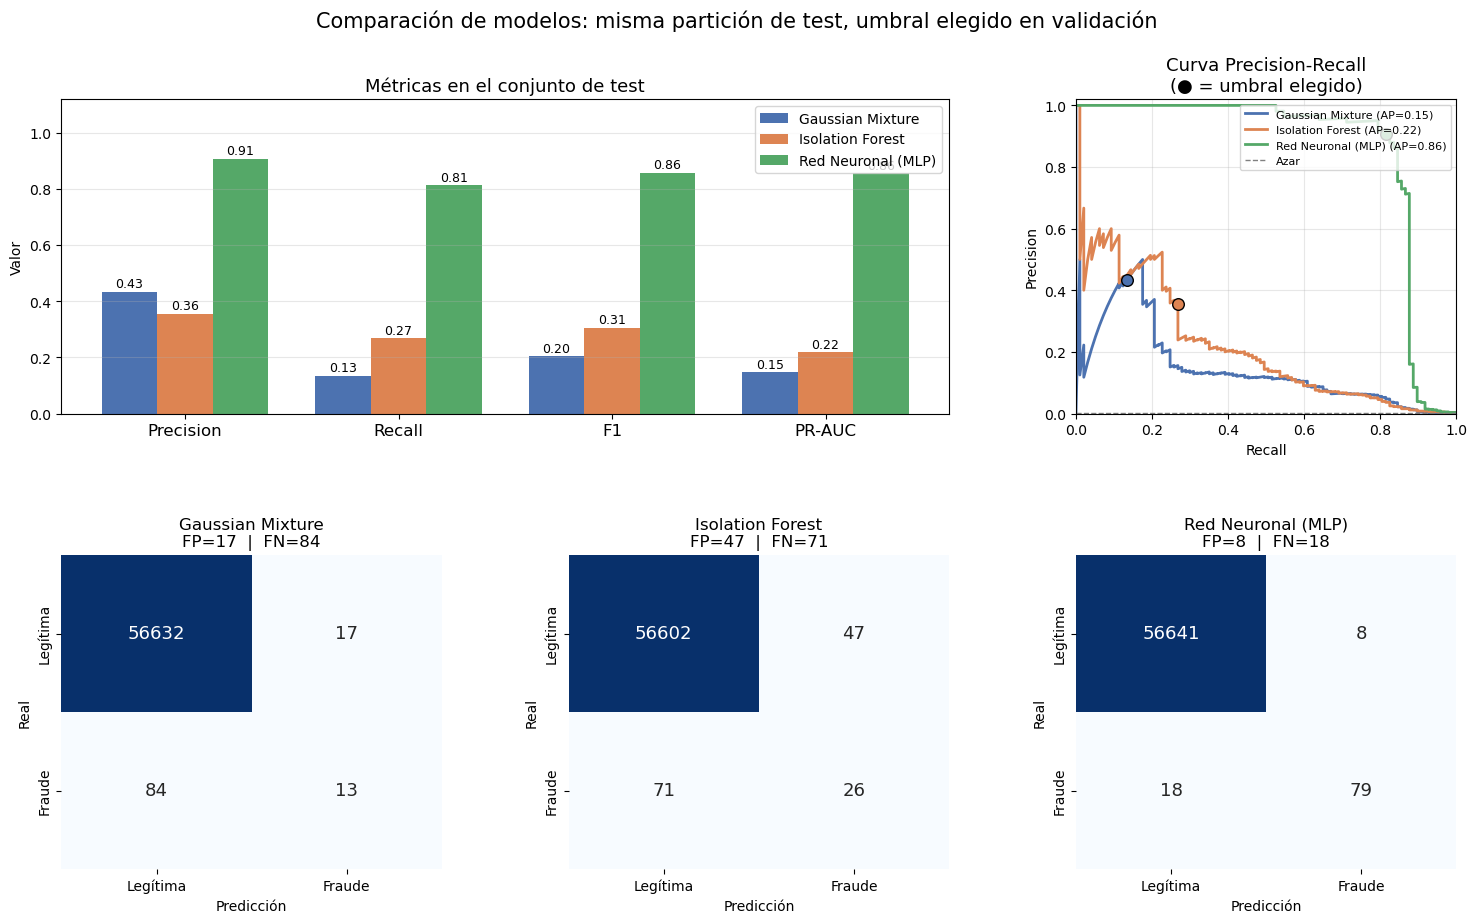

In [79]:
# Visualización comparativa de los 3 modelos (conjunto de test)
metric_names = ["Precision", "Recall", "F1", "PR-AUC"]
palette = dict(zip(results.index, sns.color_palette("deep", len(results))))
n_models = len(results)

fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2, 6, hspace=0.45, wspace=1.0)

# 1) Barras agrupadas con las métricas principales
ax = fig.add_subplot(gs[0, 0:4])
x = np.arange(len(metric_names))
w = 0.26
for k, (name, row) in enumerate(results.iterrows()):
    vals = row[metric_names].astype(float).values
    pos = x + (k - (n_models - 1) / 2) * w
    ax.bar(pos, vals, w, label=name, color=palette[name])
    for xi, v in zip(pos, vals):
        ax.text(xi, v + 0.015, f"{v:.2f}", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel("Valor")
ax.set_title("Métricas en el conjunto de test", fontsize=13)
ax.grid(axis="y", alpha=0.3)
ax.legend()

# 2) Curvas Precision-Recall (la línea punteada es el azar: proporción de fraudes)
ax = fig.add_subplot(gs[0, 4:6])
for name, c in candidates.items():
    p, r, _ = precision_recall_curve(y_test, c["scores_test"])
    ax.plot(r, p, color=palette[name], lw=2, label=f"{name} (AP={results.loc[name, 'PR-AUC']:.2f})")
    # punto de operación (umbral elegido en validación)
    ax.scatter(results.loc[name, "Recall"], results.loc[name, "Precision"],
               color=palette[name], edgecolor="k", s=70, zorder=3)
ax.axhline(y_test.mean(), color="gray", ls="--", lw=1, label="Azar")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_title("Curva Precision-Recall\n(● = umbral elegido)", fontsize=13)
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=8)

# 3) Matrices de confusión
for k, (name, c) in enumerate(candidates.items()):
    ax = fig.add_subplot(gs[1, 2 * k:2 * k + 2])
    sns.heatmap(c["cm"], annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Legítima", "Fraude"], yticklabels=["Legítima", "Fraude"],
                annot_kws={"fontsize": 13})
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    ax.set_title(f"{name}\nFP={c['cm'][0, 1]}  |  FN={c['cm'][1, 0]}", fontsize=12)

fig.suptitle("Comparación de modelos: misma partición de test, umbral elegido en validación",
             fontsize=15, y=0.97)
plt.show()


### Conclusion Final

**Desbalance extremo.** Tras eliminar 1.081 duplicados quedan 283.726 transacciones y solo **473 fraudes (0,17 %)**. Un clasificador que respondiera siempre "legítima" tendría una accuracy del 99,83 %; de hecho, la accuracy de la red neuronal ya ronda 0,9993–0,9995 desde la primera época (ver curvas de entrenamiento). La accuracy **no sirve** para evaluar este problema, por eso la selección se basa en Precision, Recall, F1 y PR-AUC.

**Histogramas por clase.** Las variables no aportan lo mismo:
- **V4 y V11** se desplazan hacia valores positivos en los fraudes (centradas cerca de +4, contra ≈0 en las legítimas).
- **V10, V12, V14, V16 y V17** se desplazan hacia valores negativos (entre −5 y −8) y con colas largas que llegan a −15 o −25, mientras las legítimas forman un pico estrecho en 0.
- **V13, V15, V22 y V24–V28** se superponen casi por completo: aportan poca información para separar las clases.
- **Time**: las legítimas muestran dos picos (cerca de 50.000 s y 150.000 s) que sugieren un ciclo diario. En los fraudes la forma es más irregular, pero con 473 casos el histograma es ruidoso y no hay evidencia de que sea discriminante.
- **Amount** se concentra cerca de 0 con una cola larga (hasta ≈25.000); su correlación con `Class` es 0,01.

**Dispersión V10 vs V14.** Los fraudes (rojo) forman una nube desplazada hacia abajo y a la izquierda (V14 entre −5 y −15, V10 entre −3 y −20), bien separada del núcleo legítimo. Pero una parte de los fraudes queda **dentro** del núcleo denso, cerca de (0, 0): con estas dos variables esos casos son indistinguibles de una transacción normal. Esto fija un techo para cualquier modelo de 2 dimensiones.

**Correlaciones.**
- *Pearson*: V1–V28 están prácticamente incorrelacionadas entre sí (esperable, son componentes principales), así que no hay multicolinealidad. Las más asociadas a `Class` son V17 (−0,31), V14 (−0,29), V12 (−0,25), V10 (−0,21), V16 (−0,19), V3 (−0,18), V7 (−0,17), V11 (+0,15) y V4 (+0,13). Coincide con el ranking de importancia del Random Forest (V17, V14, V12, V10, V16, V11 al frente).
- *Spearman*: las correlaciones con `Class` caen a |ρ| ≤ 0,06 y aparecen dependencias entre variables que Pearson no mostraba (V21–V22 = 0,68; V27–V28 = 0,46; V6–V8 = 0,45; V23–V25 = −0,43). Una lectura razonable es que la señal de fraude vive en **valores extremos** (las colas), que pesan mucho en Pearson pero se diluyen al trabajar con rangos. Por eso conviene modelos no lineales o de detección de anomalías, y no depender de correlaciones simples.
- `Amount` está correlacionada con varias componentes (V2 −0,53; V7 0,40; V5 −0,39; V20 0,34) pero casi nada con `Class`.

2. Modelos

Resultados ya obtenidos en el notebook (**no son comparables entre sí**: distinta partición y distinto umbral):

| Modelo | Variables | Evaluado sobre | Precision | Recall | F1 |
| :--- | :---: | :--- | :---: | :---: | :---: |
| Gaussian Mixture | V10, V14 | dataset completo, percentil 0,03 | 0,81 | 0,15 | 0,25 |
| Gaussian Mixture | 28 | dataset completo, umbral −470 | 0,57 | 0,33 | 0,42 |
| Isolation Forest | V10, V14 | dataset completo, contamination = 0,01 | 0,13 | 0,79 | 0,23 |
| Isolation Forest | 28 | dataset completo, contamination = 0,015 | 0,07 | 0,66 | 0,13 |
| Red neuronal | V10, V14 | test | – | – | 0,80 |
| Red neuronal | 20 | test | – | – | 0,838 |

**Gaussian Mixture.** Los contornos muestran que el modelo ubica la masa de densidad sobre las transacciones legítimas, y los fraudes extremos (V10 < −10, V14 < −8) caen en los anillos de baja densidad: ahí funciona. Los fraudes que están dentro del núcleo tienen densidad alta y pasan inadvertidos. Es un detector **conservador**: con 2 variables marcó 86 casos y acertó 70 (alta precision, recall de solo 15 %); con 28 variables duplicó el recall a costa de la precision. La búsqueda de hiperparámetros no aportó información (ver limitaciones).

**Isolation Forest.** Su función de decisión dibuja regiones rectangulares alineadas con los ejes, típicas de los árboles. Es el modelo **opuesto**: detecta casi todos los fraudes (recall 79 %) pero genera muchas falsas alarmas (≈6,6 transacciones legítimas por cada fraude detectado). La cola derecha de transacciones legítimas (V10 > 5) también queda marcada como anómala: son raras, pero no fraudulentas. Con las 28 variables empeoró, lo que sugiere que las variables sin señal (V13, V15, V22–V28) le restan capacidad de aislar.

**Red neuronal.** En las curvas, la accuracy está saturada y no informa; la señal útil es el **loss**: el de entrenamiento baja de forma constante (0,0071 → 0,0019), pero el de validación toca su mínimo cerca de la época 4 (≈0,0030) y luego sube hasta ≈0,0043, señal de **sobreajuste incipiente**. La frontera de decisión con 2 variables es no lineal y separa bien la nube de fraudes del núcleo legítimo; lo que no puede hacer es separar los fraudes que están dentro del núcleo. Al pasar a 20 variables el F1 en test subió de 0,80 a 0,838. Es una mejora a favor de usar más información, pero hay que leerla con cautela: el test tiene unos ≈95 fraudes y una sola transacción de diferencia mueve el recall cerca de 1 punto.

 3. Comparación directa

La figura anterior evalúa los tres modelos con el mismo criterio. Cómo leerla:
- **Barras**: resumen de Precision, Recall, F1 y PR-AUC en test. El F1 equilibra los dos tipos de error y la PR-AUC resume el desempeño para todos los umbrales.
- **Curvas Precision-Recall**: cuanto más cerca de la esquina superior derecha, mejor. La línea punteada es el azar (≈0,17 %). Los puntos marcan el umbral elegido en validación.
- **Matrices de confusión**: muestran el costo concreto de cada modelo en falsas alarmas (FP) y fraudes no detectados (FN).

Los modelos no supervisados detectan lo **raro**, no lo **fraudulento**: no usan las etiquetas, por lo que confunden transacciones legítimas inusuales con fraudes y no ven los fraudes que "parecen normales". La red neuronal, al aprender de las etiquetas, puede combinar muchas variables para separar ambas clases. En las corridas previas los modelos no supervisados quedaron en F1 ≈ 0,13–0,42 frente a 0,80–0,84 de la red; la celda siguiente confirma el ranking con el criterio común y selecciona el modelo automáticamente.

4. Criterio de selección

Se elige el modelo con **mayor F1 en test** (desempate por PR-AUC), porque equilibra detectar fraudes (recall) con no bloquear clientes legítimos (precision) y, a diferencia de la accuracy, no se distorsiona con el desbalance. En un caso real el umbral puede moverse según el costo relativo de un fraude no detectado frente a una falsa alarma.

5. Limitaciones y próximos pasos

- La partición **no está estratificada**: el número de fraudes en validación y test es aleatorio (≈95 en test). Conviene `stratify="Class"` y repetir con varias semillas o validación cruzada antes de dar un F1 por definitivo.
- Usar **early stopping** sobre `val_loss` (el mínimo está cerca de la época 4) y probar `class_weight` o técnicas de remuestreo para la red.
- `GaussianAnomalyDetector.set_params` tiene un `return` dentro del `for` y asigna `threshold`, mientras `predict` usa `_threshold`: el valor nunca cambia, lo que explica que los 5 candidatos de `RandomizedSearchCV` den exactamente el mismo F1 (0,0057, compatible con marcar casi todo como fraude). Además el rango 0,01–5 no corresponde a la escala de log-densidad (≈ −450).
- `select_threshold` maximiza la **precision**, que mejora de forma trivial al endurecer el umbral (devolvió −600, el borde del rango). Es preferible maximizar F1. En el GMM multidimensional también se usó −470 en vez del percentil calculado (−446,6).
- Probar modelos supervisados de árboles (el Random Forest ya entrenado, o gradient boosting) como línea base adicional.


In [80]:
ranking = results.sort_values(["F1", "PR-AUC"], ascending=False)
best_name = ranking.index[0]
best = candidates[best_name]

print("Ranking de modelos (F1 en test):")
display(ranking[["Precision", "Recall", "F1", "PR-AUC"]].round(4))
print(f"\n>>> Mejor modelo: {best_name}")
print(f"    F1 = {ranking.loc[best_name, 'F1']:.4f} | "
      f"Precision = {ranking.loc[best_name, 'Precision']:.4f} | "
      f"Recall = {ranking.loc[best_name, 'Recall']:.4f} | "
      f"PR-AUC = {ranking.loc[best_name, 'PR-AUC']:.4f}")


Ranking de modelos (F1 en test):


,Precision,Recall,F1,PR-AUC
Red Neuronal (MLP),0.9080,0.8144,0.8587,0.8559
Isolation Forest,0.3562,0.2680,0.3059,0.2194
Gaussian Mixture,0.4333,0.1340,0.2047,0.1467



>>> Mejor modelo: Red Neuronal (MLP)
    F1 = 0.8587 | Precision = 0.9080 | Recall = 0.8144 | PR-AUC = 0.8559


In [81]:
MODEL_DIR = "modelos"
os.makedirs(MODEL_DIR, exist_ok=True)

if best["type"] == "keras":
    model_path = os.path.join(MODEL_DIR, "mejor_modelo_fraude.keras")
    best["model"].save(model_path)
else:
    model_path = os.path.join(MODEL_DIR, "mejor_modelo_fraude.joblib")
    joblib.dump(best["model"], model_path)

metadata = {
    "modelo": best_name,
    "archivo_modelo": os.path.basename(model_path),
    "variables_entrada": best["features"],
    "umbral_decision": best["threshold"],
    "regla": "se marca como fraude si el puntaje >= umbral_decision",
    "metricas_test": {k: round(float(ranking.loc[best_name, k]), 4)
                      for k in ["Precision", "Recall", "F1", "PR-AUC", "ROC-AUC"]},
}
meta_path = os.path.join(MODEL_DIR, "mejor_modelo_fraude_meta.json")
with open(meta_path, "w", encoding="utf-8") as fh:
    json.dump(metadata, fh, indent=2, ensure_ascii=False)

print(f"\nModelo guardado en:    {model_path}")
print(f"Metadatos guardados en: {meta_path}")


Modelo guardado en:    modelos\mejor_modelo_fraude.keras
Metadatos guardados en: modelos\mejor_modelo_fraude_meta.json
